# N1 · 装配检查 + 统一生成画廊

> 配套 13.7-L1/L2 · capstone 的「亲手把全链跑一遍」:
> ① **装配检查**: 一次 import M13 全 6 专题的 src, 证明它们组合成一个栈 (你真的能驱动每一种生成方法)。
> ② **统一生成画廊**: 一口气驱动扩散/流匹配/DiT/dLLM 四种生成, 同屏对比。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import generative_capstone as gc
gc.add_paths()   # 把 M13 全 6 专题的 src 加进 path

## 1. 装配检查: M13 全链 import + 最小烟测 (跨专题 src 复用)

In [2]:
for topic, ok, detail in gc.assembly_check():
    print(f"  [{'OK ' if ok else 'FAIL'}] {topic:22} {detail}")
print("\n→ 全 6 专题的 src 都能 import + 跑通最小烟测 = 你掌握了完整的生成式媒体栈。")

  [OK ] 13.1 diffusion         two_moons (64, 2) + 去噪器 build
  [OK ] 13.2 flow_matching     velocity field build, data (64, 2)
  [OK ] 13.3 dit               4类blobs (120, 2) + DiT build
  [OK ] 13.4 video             轨迹 (20, 12, 2), 连贯 0.447
  [OK ] 13.5 world_model       转移 (100, 2) + WM build
  [OK ] 13.6 dLLM              回文 (50, 6)

→ 全 6 专题的 src 都能 import + 跑通最小烟测 = 你掌握了完整的生成式媒体栈。


## 2. 统一生成画廊: 一口气驱动四种生成方法

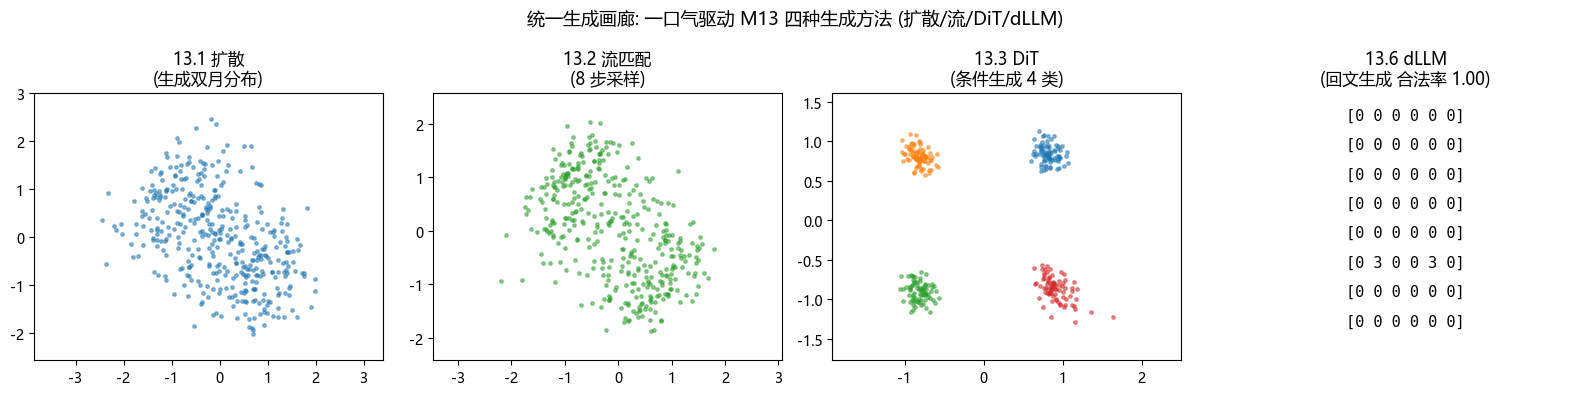

→ 扩散(双月) / 流匹配(8步) / DiT(条件4类) / dLLM(回文 1.00) 全部由你驱动。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import numpy as np, torch
import diffusion as d, flow_matching as fm, dit, diffusion_lm as dl
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# (a) 13.1 扩散: 2D 双月
torch.manual_seed(0)
x0 = d.make_two_moons(400, seed=0)
m = d.build_denoiser(); _, sched = d.train_diffusion(m, x0, epochs=300)
gen = d.sample(m, sched, n=400, dim=2, seed=1)
axes[0].scatter(gen[:,0], gen[:,1], s=6, alpha=0.5, color='C0')
axes[0].set_title('13.1 扩散\n(生成双月分布)'); axes[0].axis('equal')

# (b) 13.2 流匹配: 少步采样
torch.manual_seed(0)
x1 = fm.make_two_moons(400, seed=0)
vf = fm.build_velocity_field(); fm.train_flow_matching(vf, x1, epochs=300)
genf = fm.sample(vf, n=400, dim=2, steps=8, seed=1)
axes[1].scatter(genf[:,0], genf[:,1], s=6, alpha=0.5, color='C2')
axes[1].set_title('13.2 流匹配\n(8 步采样)'); axes[1].axis('equal')

# (c) 13.3 DiT: 条件生成 (4 类)
torch.manual_seed(0)
xb, yb = dit.make_class_blobs(n_per=150, seed=0)
dm = dit.build_dit(); _, dsched = dit.train_dit(dm, xb, yb, epochs=400)
for c in range(4):
    s = dit.sample(dm, dsched, cls=c, n=80, guidance=2.0, seed=3)
    axes[2].scatter(s[:,0], s[:,1], s=6, alpha=0.5, color=f'C{c}')
axes[2].set_title('13.3 DiT\n(条件生成 4 类)'); axes[2].axis('equal')

# (d) 13.6 dLLM: 文本(回文)生成
torch.manual_seed(0)
data = dl.make_sequences(1500, seed=0)
dlm = dl.build_dlm(d_model=80); dl.train_dlm(dlm, data, epochs=500)
gens = dl.generate_dlm(dlm, n=200, rounds=dl.L, seed=1)
valid = dl.is_palindrome(gens)
axes[3].axis('off'); axes[3].set_title(f'13.6 dLLM\n(回文生成 合法率 {valid:.2f})')
for i, s in enumerate(gens[:8]):
    axes[3].text(0.5, 0.9-i*0.11, str(s), ha='center', fontsize=11, family='monospace')
plt.suptitle('统一生成画廊: 一口气驱动 M13 四种生成方法 (扩散/流/DiT/dLLM)', fontsize=13)
plt.tight_layout(); plt.show()
print(f'→ 扩散(双月) / 流匹配(8步) / DiT(条件4类) / dLLM(回文 {valid:.2f}) 全部由你驱动。')

## 3. 反思
你亲手把 M13 全链跑了一遍。带走:
- **装配检查**: 6 个专题的 src 组合成一个栈 —— 你掌握的是完整生成式媒体栈, 不是碎片。
- **统一生成**: 同一套「生成=预测」信念下, 四种方法 (连续扩散/流/条件 DiT/离散 dLLM) 全跑通。
- 真实系统 (SD/Sora) = 这些部件 + 规模 (L2 已拆解), 你懂每一块。
下一步 N2: 从「会用」到「能推进」—— 产出 M13 的研究 idea 卡。